# Day 2 — DBSCAN & Hierarchical Clustering

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(
    r"C:\Users\Hp\Desktop\binx_mohammadabuhamed\binx_mohammadabuhamed\Cardiac Patients\data\dataprocessed_heart_data.csv"
)
X = df.drop("has_heart_disease", axis=1)
X_numeric = X.select_dtypes(include="number")
X_scaled=StandardScaler().fit_transform(X_numeric)


## step 1- DBSCAN Clustering

In [47]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=2.9,min_samples=6)
labels=db.fit_predict(X_scaled)
pd.Series(labels).value_counts()


-1     5655
 0     3147
 3      113
 1       43
 9        7
 10       6
 8        6
 6        6
 7        6
 4        5
 2        3
 5        3
Name: count, dtype: int64

### DBSCAN Results

Using `eps=2.9` and `min_samples=6`, DBSCAN identified **11 clusters** and **5,655 noise points**.

A large portion of the dataset was classified as noise, while Cluster 0 was the largest cluster with 3,147 patients.

This indicates that with these DBSCAN parameters, the dataset does not form a small number of clearly dense clusters.

## step 2- Hierarchical Clustering



Hierarchical Clustering builds a hierarchy of clusters by starting with individual data points and repeatedly merging the closest groups.

A dendrogram is used to visualize this hierarchical structure and help determine a suitable number of clusters.

take a sample because the data is too large 

In [50]:
X_sapmle=X_scaled[:500]

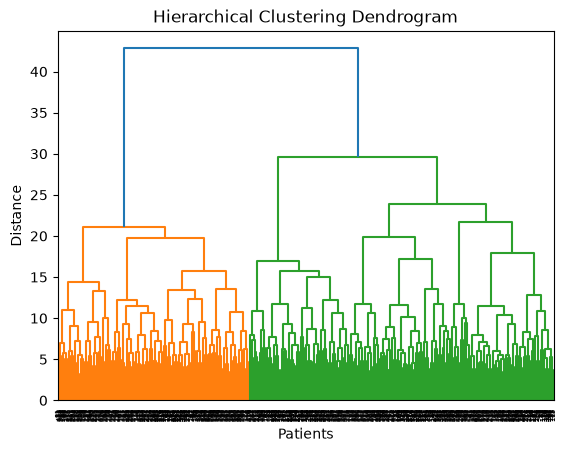

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt 
z=linkage(X_sapmle,method='ward')
dendrogram(z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Patients")
plt.ylabel("Distance")

plt.show()



The dendrogram shows how individual patients and smaller clusters are gradually merged based on their similarity.

The height of each merge represents the distance between the groups being combined. A higher merge indicates that the groups were more different from each other.

A large gap can be observed between the major merge at approximately 30 and the final merge at approximately 43, suggesting that a natural separation may exist between the two main groups.

### Dendrogram with Cut Height at 33

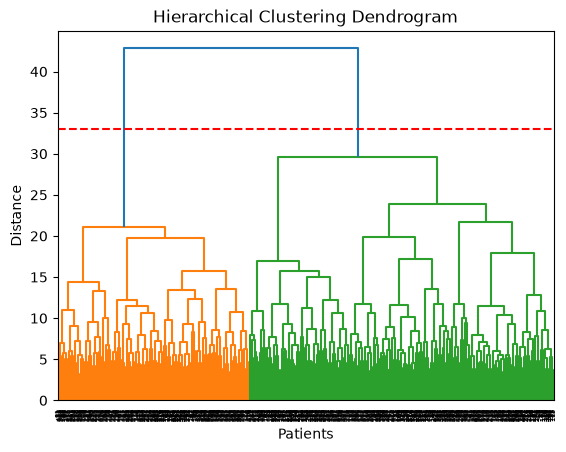

In [52]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt 
z=linkage(X_sapmle,method='ward')
dendrogram(z)
plt.axhline(y=33, color="red", linestyle="--")
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Patients")
plt.ylabel("Distance")

plt.show()




A cut height of 33 was selected because it lies within the large gap between the major merges at approximately 30 and 43.

At this height, the dendrogram is divided into two main branches, resulting in 2 clusters.

This suggests that a two-cluster structure is a reasonable representation of the sampled data.

## step 3- Comparison of Clustering Methods




### K-Means

K-Means divided the dataset into **2 clusters**.

It produced two relatively large groups and assigned every patient to a cluster. Unlike DBSCAN, K-Means does not identify noise points.

### DBSCAN

Using `eps=2.9` and `min_samples=6`, DBSCAN identified **11 clusters** and **5,655 noise points**.

Most of the dataset was classified as noise, while one large cluster contained most of the non-noise observations. This indicates that these DBSCAN parameters did not produce a small number of clear dense groups.

### Hierarchical Clustering

The hierarchical clustering dendrogram was created using a sample of **500 patients**.

A cut height of approximately **35** produced **2 main clusters** in the sampled data.

### Comparison

K-Means and Hierarchical Clustering both suggest that a two-cluster structure may be reasonable for the data.

DBSCAN produced a very different result, identifying many noise points and several small clusters.

## step 4- Choosing the Best Clustering Method

Based on the clustering results, **K-Means appears to be the most suitable method for this dataset**.

K-Means produced **2 relatively balanced clusters**, while Hierarchical Clustering also suggested a possible two-cluster structure in the sampled data.

DBSCAN, using `eps=2.9` and `min_samples=6`, classified **5,655 patients as noise** and produced several small clusters. This suggests that DBSCAN with these parameters does not fit the structure of this dataset as well as K-Means.

Therefore, K-Means provides the clearest and most practical clustering result among the three methods tested.